# DAOD Data Sanity

This notebook loads the DAOD config from `configs/daod/` and verifies dataset dispatch, sample counts, file paths, annotation parsing, detectron2-style dicts, and wrapper compatibility.

In [14]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import Visualizer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import build_daod_dataset, materialize_daod_dicts
from src.data.transforms import build_strong_transform, build_weak_transform
from src.data.wrappers import IdFilteredDataset, LabelRouterDataset, TwoViewDataset

CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)
CONFIG_PATH


PosixPath('/local/home/ljzhang/code/SFADA/configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml')

In [2]:
source_train = build_daod_dataset(cfg, "source_train", transform=None)
source_val = build_daod_dataset(cfg, "source_val", transform=None)
target_train = build_daod_dataset(cfg, "target_train", transform=None)
target_val = build_daod_dataset(cfg, "target_val", transform=None)

{
    "source_train": len(source_train),
    "source_val": len(source_val),
    "target_train": len(target_train),
    "target_val": len(target_val),
}


{'source_train': 2975,
 'source_val': 500,
 'target_train': 2975,
 'target_val': 500}

In [3]:
source_sample = source_val[0]
target_sample = target_val[0]

for sample in [source_sample, target_sample]:
    assert Path(sample["file_name"]).exists()
    assert sample["height"] > 0 and sample["width"] > 0
    assert isinstance(sample["annotations"], list)
    assert isinstance(sample["sample_id"], str)

source_sample


{'sample_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'file_name': '/home/ljzhang/data/ins-seg/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png',
 'image_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'height': 1024,
 'width': 2048,
 'annotations': [{'bbox': [949.0, 406.0, 965.0, 445.0],
   'bbox_mode': 0,
   'category_id': 0,
   'segmentation': [[960.0,
     444.0,
     960.0,
     439.0,
     960.0,
     430.0,
     961.0,
     428.0,
     964.0,
     428.0,
     965.0,
     425.0,
     965.0,
     421.0,
     962.0,
     418.0,
     959.0,
     415.0,
     958.0,
     411.0,
     957.0,
     409.0,
     955.0,
     406.0,
     955.0,
     406.0,
     954.0,
     406.0,
     951.0,
     408.0,
     949.0,
     413.0,
     949.0,
     419.0,
     951.0,
     430.0,
     952.0,
     433.0,
     952.0,
     435.0,
     954.0,
     440.0,
     954.0,
     442.0,
     954.0,
     443.0,
     955.0,
     445.0,
     959.0,
     445.0]],
   'iscro

In [4]:
print("source annotations:", len(source_sample["annotations"]))
print("target annotations:", len(target_sample["annotations"]))
source_sample["annotations"][:2]


source annotations: 7
target annotations: 7


[{'bbox': [949.0, 406.0, 965.0, 445.0],
  'bbox_mode': 0,
  'category_id': 0,
  'segmentation': [[960.0,
    444.0,
    960.0,
    439.0,
    960.0,
    430.0,
    961.0,
    428.0,
    964.0,
    428.0,
    965.0,
    425.0,
    965.0,
    421.0,
    962.0,
    418.0,
    959.0,
    415.0,
    958.0,
    411.0,
    957.0,
    409.0,
    955.0,
    406.0,
    955.0,
    406.0,
    954.0,
    406.0,
    951.0,
    408.0,
    949.0,
    413.0,
    949.0,
    419.0,
    951.0,
    430.0,
    952.0,
    433.0,
    952.0,
    435.0,
    954.0,
    440.0,
    954.0,
    442.0,
    954.0,
    443.0,
    955.0,
    445.0,
    959.0,
    445.0]],
  'iscrowd': 0,
  'area': 369.5},
 {'bbox': [1006.0, 410.0, 1032.0, 435.0],
  'bbox_mode': 0,
  'category_id': 2,
  'segmentation': [[1022.0,
    410.0,
    1015.0,
    410.0,
    1012.0,
    412.0,
    1008.0,
    418.0,
    1006.0,
    425.0,
    1006.0,
    431.0,
    1008.0,
    434.0,
    1011.0,
    435.0,
    1013.0,
    432.0,
    1023.0,
    4

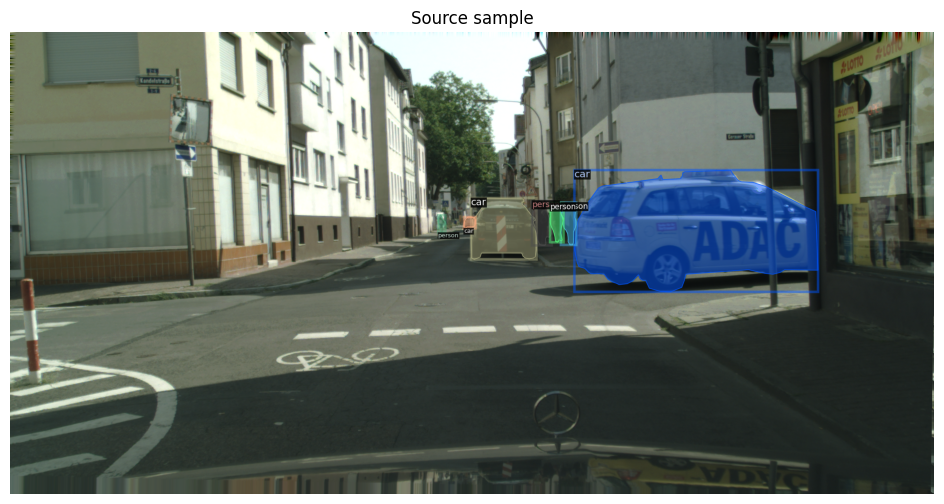

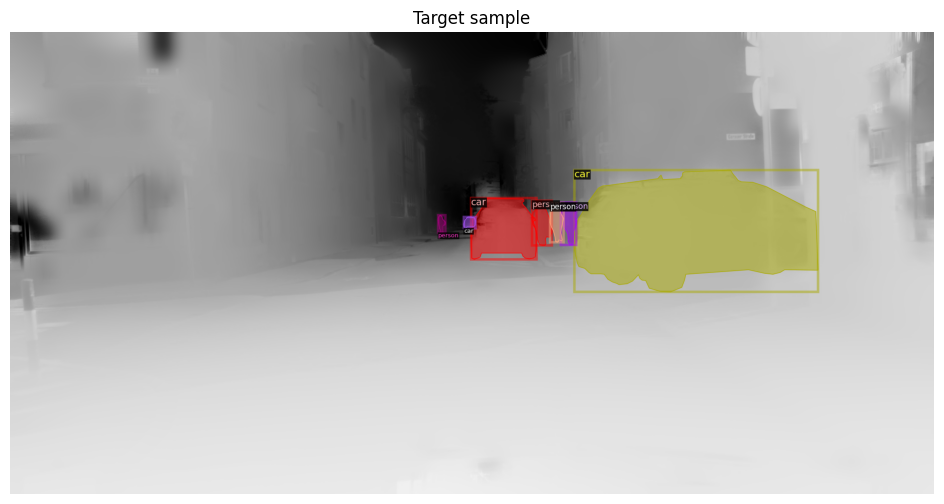

In [5]:
metadata = MetadataCatalog.get("daod_data_sanity")
metadata.set(thing_classes=list(source_val.thing_classes))

def visualize_sample(sample, title):
    image = np.asarray(Image.open(sample["file_name"]).convert("RGB"))
    vis = Visualizer(image, metadata=metadata)
    rendered = vis.draw_dataset_dict(sample).get_image()
    plt.figure(figsize=(12, 6))
    plt.imshow(rendered)
    plt.title(title)
    plt.axis("off")


visualize_sample(source_sample, "Source sample")
visualize_sample(target_sample, "Target sample")


In [6]:
source_val_dicts = materialize_daod_dicts(cfg, "source_val")
target_val_dicts = materialize_daod_dicts(cfg, "target_val")

assert isinstance(source_val_dicts, list)
assert "sample_id" in source_val_dicts[0]
assert "annotations" in source_val_dicts[0]
assert isinstance(source_val_dicts[0]["image_id"], int)

source_val_dicts[0]


{'sample_id': 'source_val:frankfurt:frankfurt_000000_000294',
 'file_name': '/home/ljzhang/data/ins-seg/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png',
 'image_id': 1,
 'height': 1024,
 'width': 2048,
 'annotations': [{'bbox': [949.0, 406.0, 965.0, 445.0],
   'bbox_mode': 0,
   'category_id': 0,
   'segmentation': [[960.0,
     444.0,
     960.0,
     439.0,
     960.0,
     430.0,
     961.0,
     428.0,
     964.0,
     428.0,
     965.0,
     425.0,
     965.0,
     421.0,
     962.0,
     418.0,
     959.0,
     415.0,
     958.0,
     411.0,
     957.0,
     409.0,
     955.0,
     406.0,
     955.0,
     406.0,
     954.0,
     406.0,
     951.0,
     408.0,
     949.0,
     413.0,
     949.0,
     419.0,
     951.0,
     430.0,
     952.0,
     433.0,
     952.0,
     435.0,
     954.0,
     440.0,
     954.0,
     442.0,
     954.0,
     443.0,
     955.0,
     445.0,
     959.0,
     445.0]],
   'iscrowd': 0,
   'area': 369.5},
  {'bbox': [1006.0

In [11]:
queried_ids = {target_val.get_sample_id(0)}
pseudo_ids = {target_val.get_sample_id(1)}
pseudo_store = {target_val.get_sample_id(1): target_val[1]["annotations"]}
router = LabelRouterDataset(target_val, queried_ids=queried_ids, pseudo_store=pseudo_store, unlabeled_label=[])
router_labeled = router[0]
router_pseudo = router[1]
router_pool = router[2]

assert router_labeled["sample_id"] == target_val.get_sample_id(0)
assert "annotations" in router_labeled
assert router_pseudo["sample_id"] in pseudo_ids
assert router_pseudo["annotations"] == pseudo_store[router_pseudo["sample_id"]]
assert router_pool["annotations"] == []

router_labeled.keys(), router_pseudo.keys(), router_pool.keys()


(dict_keys(['sample_id', 'file_name', 'image_id', 'height', 'width', 'annotations']),
 dict_keys(['sample_id', 'file_name', 'image_id', 'height', 'width', 'annotations']),
 dict_keys(['sample_id', 'file_name', 'image_id', 'height', 'width', 'annotations']))

In [12]:
labeled = IdFilteredDataset(router, mode="labeled")
pseudo = IdFilteredDataset(router, mode="pseudo")
pool = IdFilteredDataset(router, mode="pool")
assert len(labeled) == 1
assert len(pseudo) == 1
assert labeled[0]["sample_id"] in queried_ids
assert pseudo[0]["sample_id"] in pseudo_ids
assert pool[0]["sample_id"] not in queried_ids
assert pool[0]["sample_id"] not in pseudo_ids
len(labeled), len(pseudo), len(pool), labeled[0]["sample_id"], pseudo[0]["sample_id"]


(1,
 1,
 498,
 'target_val:frankfurt:frankfurt_000000_000294:beta=0.02',
 'target_val:frankfurt:frankfurt_000000_000576:beta=0.02')

In [15]:
weak_tf = build_weak_transform(cfg)
strong_tf = build_strong_transform(cfg)
two_view = TwoViewDataset(source_val, weak_tf=weak_tf, strong_tf=strong_tf)
two_view_sample = two_view[0]

assert two_view_sample["sample_id"] == source_val.get_sample_id(0)
assert "x_w" in two_view_sample and "x_s" in two_view_sample
assert "annotations" in two_view_sample
assert two_view_sample["x_w"].shape[1:] == two_view_sample["x_s"].shape[1:]

two_view_sample["sample_id"], two_view_sample["x_w"].shape, two_view_sample["x_s"].shape, type(two_view_sample["annotations"])


('source_val:frankfurt:frankfurt_000000_000294',
 torch.Size([3, 224, 224]),
 torch.Size([3, 224, 224]),
 list)